<a href="https://colab.research.google.com/github/lhklhk04/undergrad-research/blob/main/%EC%9A%B4%EB%8F%99%EC%8B%9C%EA%B0%84_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 일주일 운동시간 분석
헬스, 런닝, 농구, 수영 4가지 운동 중 하루에 한 종류씩 기록하고
평균/합계, 목표 달성률, 운동 종류별 비중을 분석합니다.

## 1. 변수와 출력문 사용

In [2]:
name = "홍기"
week = "7월 4주차"
goal_total_minutes = 180  # 일주일 목표 총 운동시간(분)

print(f"{name}님의 {week} 운동시간 기록입니다.")
print(f"이번 주 목표 총 운동시간: {goal_total_minutes}분")

홍기님의 7월 4주차 운동시간 기록입니다.
이번 주 목표 총 운동시간: 180분


## 2. 리스트에 데이터 저장
운동 종류는 헬스, 런닝, 농구, 수영 4가지로 고정합니다.

In [3]:
days = ["월", "화", "수", "목", "금", "토", "일"]
exercise_minutes = [60, 60, 0, 50, 50, 0, 0]
exercise_type = ["헬스", "수영", "휴식", "헬스", "헬스", "휴식", "휴식"]

for d, m, t in zip(days, exercise_minutes, exercise_type):
    print(f"{d}요일: {m}분 ({t})")

월요일: 60분 (헬스)
화요일: 60분 (수영)
수요일: 0분 (휴식)
목요일: 50분 (헬스)
금요일: 50분 (헬스)
토요일: 0분 (휴식)
일요일: 0분 (휴식)


## 3. 평균과 합계 계산

In [4]:
total = sum(exercise_minutes)
average = total / len(exercise_minutes)

print(f"이번 주 총 운동시간: {total}분")
print(f"하루 평균 운동시간: {average:.1f}분")

이번 주 총 운동시간: 220분
하루 평균 운동시간: 31.4분


## 4. [추가] 주간 목표 대비 달성률 분석

In [5]:
achievement_rate = total / goal_total_minutes * 100
remaining = goal_total_minutes - total

max_day = days[exercise_minutes.index(max(exercise_minutes))]
min_day = days[exercise_minutes.index(min(exercise_minutes))]

print(f"이번 주 목표: {goal_total_minutes}분 / 실제 운동: {total}분")
print(f"목표 달성률: {achievement_rate:.1f}%")
if remaining > 0:
    print(f"목표까지 {remaining}분 남음")
else:
    print(f"목표 달성! {-remaining}분 초과 달성")
print(f"운동을 가장 많이 한 요일: {max_day} ({max(exercise_minutes)}분)")
print(f"운동을 가장 적게 한 요일: {min_day} ({min(exercise_minutes)}분)")

이번 주 목표: 180분 / 실제 운동: 220분
목표 달성률: 122.2%
목표 달성! 40분 초과 달성
운동을 가장 많이 한 요일: 월 (60분)
운동을 가장 적게 한 요일: 수 (0분)


## 5. [추가] 운동 종류별 비중 분석 (헬스/런닝/농구/수영)

In [6]:
from collections import Counter

type_count = Counter(exercise_type)
print("운동 종류별 횟수:")
for t, c in type_count.items():
    print(f"- {t}: {c}회")

운동 종류별 횟수:
- 헬스: 3회
- 수영: 1회
- 휴식: 3회


## 6. 그래프로 시각화

In [7]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (8,011 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direc

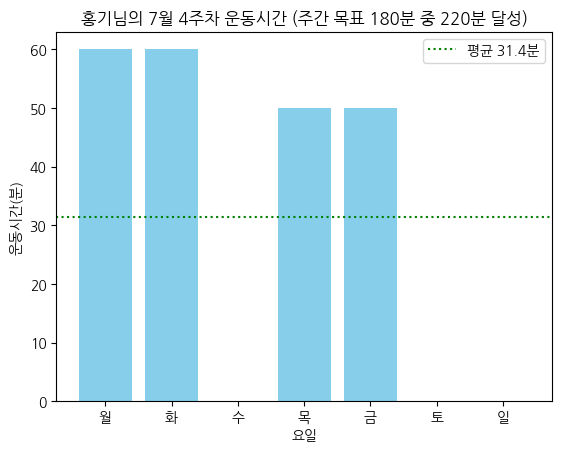

In [8]:
import matplotlib.pyplot as plt

plt.bar(days, exercise_minutes, color='skyblue')
plt.axhline(average, color='green', linestyle=':', label=f'평균 {average:.1f}분')
plt.title(f"{name}님의 {week} 운동시간 (주간 목표 {goal_total_minutes}분 중 {total}분 달성)")
plt.xlabel("요일")
plt.ylabel("운동시간(분)")
plt.legend()
plt.show()

## 7. [추가] 운동 종류별 비중 원그래프

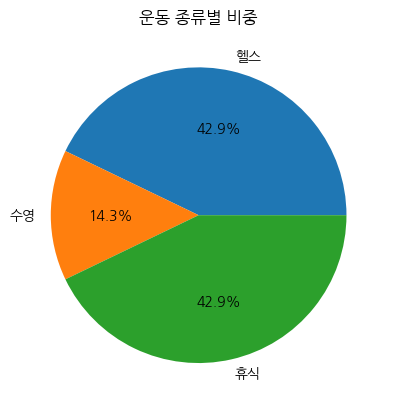

In [9]:
plt.pie(type_count.values(), labels=type_count.keys(), autopct='%1.1f%%')
plt.title("운동 종류별 비중")
plt.show()

## 8. 본인 데이터로 수정하기

In [10]:
# 실제 본인의 지난 일주일 운동시간과 종류로 수정 (헬스/런닝/농구/수영 중 선택)
exercise_minutes = [30, 0, 45, 20, 60, 0, 40]
exercise_type = ["런닝", "휴식", "헬스", "런닝", "농구", "휴식", "수영"]

total = sum(exercise_minutes)
average = total / len(exercise_minutes)
achievement_rate = total / goal_total_minutes * 100

print(f"실제 총 운동시간: {total}분, 평균: {average:.1f}분")
print(f"주간 목표 달성률: {achievement_rate:.1f}%")

실제 총 운동시간: 195분, 평균: 27.9분
주간 목표 달성률: 108.3%


## 9. [심화] 다음 주 운동 추천 시스템
이번 주 기록을 분석해서 다음 주에 어떻게 운동하면 좋을지 추천합니다.

In [11]:
def recommend_next_week(exercise_minutes, exercise_type, goal_total_minutes):
    total = sum(exercise_minutes)
    achievement_rate = total / goal_total_minutes * 100

    # 실제 운동한 날만 종류 카운트 (휴식 제외)
    active_types = [t for t in exercise_type if t != "휴식"]
    type_count = Counter(active_types)

    # 4종목 기준으로 한 번도 안 한 종목 찾기
    all_types = ["헬스", "런닝", "농구", "수영"]
    missing_types = [t for t in all_types if t not in type_count]

    # 가장 적게 한 종목 (한 번이라도 한 것 중)
    least_type = min(type_count, key=type_count.get) if type_count else None

    # 쉰 날 개수
    rest_days = exercise_minutes.count(0)

    recommendations = []

    # 1) 목표 달성률 기반 추천
    if achievement_rate < 80:
        recommendations.append(f"이번 주 목표 달성률이 {achievement_rate:.1f}%로 낮은 편이에요. 다음 주는 목표를 조금 낮추거나({int(goal_total_minutes*0.9)}분), 하루 운동 시간을 조금씩 늘려보세요.")
    elif achievement_rate >= 100:
        recommendations.append(f"이번 주 목표를 {achievement_rate:.1f}% 달성했어요! 다음 주는 목표를 {int(goal_total_minutes*1.1)}분으로 조금 올려서 도전해보세요.")
    else:
        recommendations.append(f"이번 주 목표 달성률은 {achievement_rate:.1f}%예요. 지금 페이스를 유지하면 다음 주엔 충분히 목표를 채울 수 있어요.")

    # 2) 운동 종류 균형 추천
    if missing_types:
        recommendations.append(f"이번 주에 안 한 운동이 있어요: {', '.join(missing_types)}. 다음 주엔 한 번씩 시도해보면 좋겠어요.")
    elif least_type:
        recommendations.append(f"'{least_type}'을(를) 가장 적게 했어요({type_count[least_type]}회). 다음 주엔 '{least_type}' 비중을 늘려보는 건 어때요?")

    # 3) 휴식일 기반 추천
    if rest_days == 0:
        recommendations.append("일주일 내내 쉬는 날이 없었어요. 회복을 위해 하루 정도는 휴식일로 남겨두는 걸 추천해요.")
    elif rest_days >= 4:
        recommendations.append(f"이번 주 쉰 날이 {rest_days}일로 많은 편이에요. 다음 주엔 운동 횟수를 조금 늘려보세요.")

    return recommendations, achievement_rate


# 추천 실행
tips, rate = recommend_next_week(exercise_minutes, exercise_type, goal_total_minutes)

print(f"[이번 주 요약] 총 {sum(exercise_minutes)}분 운동, 목표 달성률 {rate:.1f}%\n")
print("다음 주 추천 사항:")
for i, tip in enumerate(tips, 1):
    print(f"{i}. {tip}")

[이번 주 요약] 총 195분 운동, 목표 달성률 108.3%

다음 주 추천 사항:
1. 이번 주 목표를 108.3% 달성했어요! 다음 주는 목표를 198분으로 조금 올려서 도전해보세요.
2. '헬스'을(를) 가장 적게 했어요(1회). 다음 주엔 '헬스' 비중을 늘려보는 건 어때요?


## 10. [심화] 본인 데이터 직접 입력해서 추천받기
아래 셀을 실행하면 요일별 운동시간과 종류를 직접 입력해서
나만의 다음 주 추천을 받아볼 수 있습니다.

In [12]:
print("이번 주 운동 기록을 입력하세요. (운동 안 한 날은 0과 '휴식' 입력)")
print("운동 종류는 헬스 / 런닝 / 농구 / 수영 / 휴식 중에서 선택하세요.\n")

my_minutes = []
my_types = []

for day in days:
    m = int(input(f"{day}요일 운동시간(분): "))
    t = input(f"{day}요일 운동종류: ")
    my_minutes.append(m)
    my_types.append(t)

my_goal = int(input("\n이번 주 목표 총 운동시간(분): "))

print("\n" + "="*40)
my_tips, my_rate = recommend_next_week(my_minutes, my_types, my_goal)
print(f"[내 기록 요약] 총 {sum(my_minutes)}분 운동, 목표 달성률 {my_rate:.1f}%\n")
print("나에게 맞는 다음 주 추천 사항:")
for i, tip in enumerate(my_tips, 1):
    print(f"{i}. {tip}")

이번 주 운동 기록을 입력하세요. (운동 안 한 날은 0과 '휴식' 입력)
운동 종류는 헬스 / 런닝 / 농구 / 수영 / 휴식 중에서 선택하세요.

월요일 운동시간(분): 60
월요일 운동종류: 헬스
화요일 운동시간(분): 50
화요일 운동종류: 수영
수요일 운동시간(분): 0
수요일 운동종류: 휴식
목요일 운동시간(분): 60
목요일 운동종류: 헬스
금요일 운동시간(분): 20
금요일 운동종류: 런닝
토요일 운동시간(분): 0
토요일 운동종류: 휴식
일요일 운동시간(분): 0
일요일 운동종류: 휴식

이번 주 목표 총 운동시간(분): 180

[내 기록 요약] 총 190분 운동, 목표 달성률 105.6%

나에게 맞는 다음 주 추천 사항:
1. 이번 주 목표를 105.6% 달성했어요! 다음 주는 목표를 198분으로 조금 올려서 도전해보세요.
2. 이번 주에 안 한 운동이 있어요: 농구. 다음 주엔 한 번씩 시도해보면 좋겠어요.
